# Benamou--Brenier geodesic between two shapes

This notebook generates `fig:dynamic-benamou-brenier-geodesic`.  It samples the cat and two-disks silhouettes, computes a discrete quadratic OT plan with POT, and displays the McCann interpolation
$$
    Z_t=(1-t)X+tY, \qquad V_t=Y-X.
$$
The density sequence is rendered from a fine silhouette sample as saturated color images with local crops padded by the KDE halo so that the full silhouettes remain visible.  The velocity panel overlays explicit data-coordinate arrows centered at midpoint particles $Z_{1/2}$; these arrows are not full endpoint links, but their heads point exactly in the matched characteristic directions $Y-X$.


In [1]:
from pathlib import Path
import os
import sys
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")
for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from PIL import Image
import ot
from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, box_axes,
    interp_color, padded_limits,
)
setup_matplotlib()
rng = np.random.default_rng(2027)


In [2]:
NAME = "dynamic-benamou-brenier-geodesic"
out = figure_dir(NAME)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)

KDE_SIGMA = 0.040
DENSITY_CROP_PAD = 0.075
VELOCITY_CROP_PAD = 0.115
KDE_HALO = 2.7 * KDE_SIGMA

def load_mask_points(path, size=170):
    im = Image.open(path).convert("L").resize((size, size))
    arr = np.asarray(im) / 255.0
    mask = arr < 0.72 if arr.mean() > 0.5 else arr > 0.28
    yy, xx = np.where(mask)
    pts = np.c_[xx, -yy].astype(float)
    pts -= pts.mean(axis=0)
    pts /= max(np.linalg.norm(pts, axis=1).max(), 1e-12)
    return pts

def farthest_indices(points, n, seed=0):
    rr = np.random.default_rng(seed)
    points = np.asarray(points, dtype=float)
    start = int(rr.integers(len(points)))
    chosen = [start]
    dist2 = np.sum((points - points[start])**2, axis=1)
    for _ in range(1, min(n, len(points))):
        j = int(np.argmax(dist2))
        chosen.append(j)
        dist2 = np.minimum(dist2, np.sum((points - points[j])**2, axis=1))
    return np.asarray(chosen, dtype=int)

def farthest_point_sample(points, n, seed=0):
    return np.asarray(points, dtype=float)[farthest_indices(points, n, seed)]

n = 720
x = farthest_point_sample(load_mask_points(ROOT / "notebooks-figures/assets/cat.png"), n, seed=12) + np.array([-0.82, 0.0])
y = farthest_point_sample(load_mask_points(ROOT / "notebooks-figures/assets/twodisks.png"), n, seed=13) + np.array([0.82, 0.0])
# A very small deterministic jitter prevents exact pixel symmetries while keeping the silhouette sampling regular.
x += 0.0045 * rng.normal(size=x.shape)
y += 0.0045 * rng.normal(size=y.shape)

a = np.ones(len(x)) / len(x)
b = np.ones(len(y)) / len(y)
C = ot.dist(x, y, metric="sqeuclidean")
P = ot.emd(a, b, C)

# The displayed velocity field uses characteristics of a deterministic optimal
# assignment. Since the measures have equal weights, the EMD plan should be a
# permutation matrix scaled by 1/n; these assertions prevent accidental plotting
# of barycentric arrows if the plan ceases to be deterministic.
tol = 1e-12
positive = P > tol
np.testing.assert_allclose(P.sum(axis=1), a, atol=1e-13)
np.testing.assert_allclose(P.sum(axis=0), b, atol=1e-13)
if not (np.all(positive.sum(axis=1) == 1) and np.all(positive.sum(axis=0) == 1)):
    raise RuntimeError("The OT plan is not a permutation; midpoint velocity arrows would need barycentric averaging.")
match = np.argmax(positive, axis=1)
np.testing.assert_allclose(P[np.arange(n), match], a, atol=1e-13)

ym = y[match]
vel = ym - x
z_mid = 0.5 * (x + ym)
print(
    f"permutation OT plan: {positive.sum()} active pairs, "
    f"cost={np.sum(P * C):.6f}, velocity norm range=({np.linalg.norm(vel, axis=1).min():.3f}, {np.linalg.norm(vel, axis=1).max():.3f})"
)

allp = np.vstack([x, y])
xlim, ylim = padded_limits(allp, pad=0.055)

def tight_limits(points, pad=0.055, min_width=0.45, extra=0.0):
    pts = np.asarray(points)
    xmin, ymin = pts.min(axis=0)
    xmax, ymax = pts.max(axis=0)
    cx, cy = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
    # ``extra`` is an absolute margin in data coordinates.  It keeps the KDE
    # halo and arrow heads inside the crop even for very elongated shapes.
    w = max((xmax - xmin) + 2 * extra, min_width)
    h = max((ymax - ymin) + 2 * extra, min_width)
    w *= 1 + 2 * pad
    h *= 1 + 2 * pad
    return (cx - w / 2, cx + w / 2), (cy - h / 2, cy + h / 2)


def kde_grid(z, xlim_local, ylim_local, nx=184, ny=146, sigma=KDE_SIGMA):
    gx = np.linspace(xlim_local[0], xlim_local[1], nx)
    gy = np.linspace(ylim_local[0], ylim_local[1], ny)
    X, Y = np.meshgrid(gx, gy)
    G = np.stack([X, Y], axis=-1)
    D = ((G[:, :, None, :] - z[None, None, :, :]) ** 2).sum(axis=-1)
    den = np.exp(-D / (2 * sigma**2)).mean(axis=-1)
    return den, (xlim_local[0], xlim_local[1], ylim_local[0], ylim_local[1])


def color_density_image(H, color):
    color = np.asarray(color, dtype=float)
    vals = H[H > 0]
    scale = np.percentile(vals, 95) if len(vals) else 1.0
    v = np.clip(H / max(scale, 1e-12), 0, 1)
    return (1 - v[..., None]) * np.ones((*H.shape, 3)) + v[..., None] * color


def draw_density_panel(ax, t):
    z = (1 - t) * x + t * ym
    color = interp_color(t)
    xlim_local, ylim_local = tight_limits(z, pad=DENSITY_CROP_PAD, extra=KDE_HALO)
    den, extent = kde_grid(z, xlim_local, ylim_local)
    ax.imshow(color_density_image(den, color), extent=extent, origin="lower", interpolation="bicubic")
    ax.set_xlim(*xlim_local)
    ax.set_ylim(*ylim_local)
    ax.set_aspect("equal")
    remove_axes(ax)

sub = farthest_indices(z_mid, 92, seed=29)
arrow_scale = 8.6

# The plotted arrows are centered at z_mid and are collinear with the full
# matched segments x_i -> y_{sigma(i)}. Their length is only rescaled visually.
arrow_start = z_mid[sub] - vel[sub] / (2 * arrow_scale)
arrow_end = z_mid[sub] + vel[sub] / (2 * arrow_scale)
full_direction = ym[sub] - x[sub]
shown_direction = arrow_end - arrow_start
cross = shown_direction[:, 0] * full_direction[:, 1] - shown_direction[:, 1] * full_direction[:, 0]
dot = np.sum(shown_direction * full_direction, axis=1)
np.testing.assert_allclose(cross, 0, atol=1e-13)
if not np.all(dot > 0):
    raise RuntimeError("At least one displayed arrow is not oriented from source to target.")
if not np.all(np.linalg.norm(arrow_end - ym[sub], axis=1) < np.linalg.norm(arrow_start - ym[sub], axis=1)):
    raise RuntimeError("At least one displayed arrow head is not closer to its matched target.")
if not np.all(np.linalg.norm(arrow_start - x[sub], axis=1) < np.linalg.norm(arrow_end - x[sub], axis=1)):
    raise RuntimeError("At least one displayed arrow tail is not closer to its matched source.")

arrow_points = np.vstack([z_mid, arrow_start, arrow_end])
xlim_mid, ylim_mid = tight_limits(arrow_points, pad=VELOCITY_CROP_PAD, extra=KDE_HALO)


def draw_velocity_panel(ax):
    den_mid, extent_mid = kde_grid(z_mid, xlim_mid, ylim_mid, nx=196, ny=156)
    ax.imshow(
        color_density_image(den_mid, interp_color(0.5)),
        extent=extent_mid,
        origin="lower",
        interpolation="bicubic",
        zorder=1,
    )
    for start, end in zip(arrow_start, arrow_end):
        ax.add_patch(
            FancyArrowPatch(
                start,
                end,
                arrowstyle="-|>",
                mutation_scale=4.6,
                linewidth=0.46,
                color="black",
                alpha=0.76,
                shrinkA=0.0,
                shrinkB=0.0,
                zorder=3,
            )
        )
    ax.set_xlim(*xlim_mid)
    ax.set_ylim(*ylim_mid)
    ax.set_aspect("equal")
    remove_axes(ax)

fig, axes = plt.subplots(1, 5, figsize=(5.65, 1.22), gridspec_kw={"wspace": 0.018})
for ax, t in zip(axes, [0, 0.25, 0.5, 0.75, 1]):
    draw_density_panel(ax, t)
save_pdf(fig, out / "density-sequence.pdf", pad_inches=0.006)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.48, 1.75))
draw_velocity_panel(ax)
save_pdf(fig, out / "midpoint-velocities.pdf", pad_inches=0.008)
plt.close(fig)

fig = plt.figure(figsize=(7.30, 1.50))
grid = fig.add_gridspec(1, 6, width_ratios=[1, 1, 1, 1, 1, 1.38], wspace=0.035)
for k, t in enumerate([0, 0.25, 0.5, 0.75, 1]):
    draw_density_panel(fig.add_subplot(grid[0, k]), t)
draw_velocity_panel(fig.add_subplot(grid[0, 5]))
fig.subplots_adjust(left=0.005, right=0.995, bottom=0.015, top=0.985)
thumb_path = thumb_dir / f"{NAME}.png"
fig.savefig(thumb_path, dpi=180, facecolor="white")
plt.close(fig)

print(f"Wrote panels to {out}")
print(f"Wrote thumbnail to {thumb_path}")


permutation OT plan: 720 active pairs, cost=3.016823, velocity norm range=(0.900, 2.565)


Wrote panels to /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/dynamic-benamou-brenier-geodesic
Wrote thumbnail to /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/dynamic-benamou-brenier-geodesic.png


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


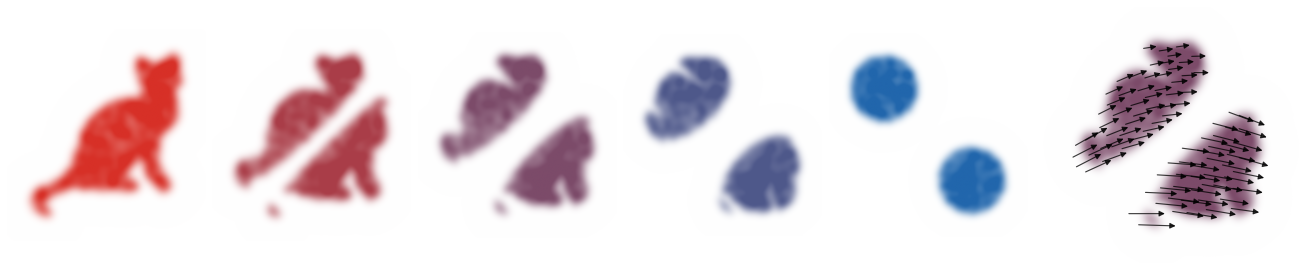

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dynamic-benamou-brenier-geodesic.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dynamic-benamou-brenier-geodesic.png")
display(Image(filename=str(_thumb)))
